# CLIP Lab: experience first, explain second

Run real OpenAI CLIP on public photographs and labelled generated pairs, inspect its vectors, and train a tiny two-encoder model from scratch.

**Predict → run → change one input → explain.** [Browser lab](https://nipunbatra.github.io/clip-lab/) · [Full source credits](https://nipunbatra.github.io/clip-lab/sources.html).

The hat subtraction idea is adapted from [CodeEmporium, 7:25](https://www.youtube.com/watch?v=FCDKn-vpn_o&t=445s). We use our own generated images, not the creator’s portraits. Search follows [Supabase](https://www.youtube.com/watch?v=S7VZErcTN5Y); similarity analysis is inspired by [Roboflow, 10:40](https://www.youtube.com/watch?v=YxJkE6FvGF4&t=640s). The mathematical method is [Radford et al. (2021)](https://proceedings.mlr.press/v139/radford21a.html).

The Python notebook uses original OpenAI weights in float32. The browser uses the pinned Xenova ONNX conversion in q8. Small score differences are expected from quantization and image resizing. All numbers below are execution outputs, not handwritten predictions.

## 0. Set up
Clone the repository and run from its root. In Colab, run the following setup cell once. Model download is approximately 338 MB for the original checkpoint. No API key or paid inference endpoint is used.

In [1]:
import os, sys, subprocess
from pathlib import Path
if 'google.colab' in sys.modules:
    if not Path('/content/clip-lab').exists():
        subprocess.run(['git','clone','https://github.com/nipunbatra/clip-lab.git','/content/clip-lab'],check=True)
    os.chdir('/content/clip-lab')
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','requirements.txt'],check=True)
ROOT = Path.cwd()
if not (ROOT/'data/gallery.json').exists(): ROOT = ROOT.parent
assert (ROOT/'data/gallery.json').exists(), 'Run inside the cloned clip-lab repository.'
print('Project:', ROOT.name)

Project: clip-lab


In [2]:
import json, numpy as np, torch, clip
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
torch.set_num_threads(2)
DEVICE = 'cpu'  # reproducible reference; choose cuda if available
model, preprocess = clip.load('ViT-B/32', device=DEVICE, jit=False)
model.eval()
gallery = json.loads((ROOT/'data/gallery.json').read_text())
experiments = json.loads((ROOT/'data/experiments.json').read_text())

def read_image(item):
    im = Image.open(ROOT/'images'/item['file']).convert('RGB')
    w,h = im.size
    if 'panel' in item:
        width=w//2; x=item['panel']*width; im=im.crop((x,0,x+width,h))
    elif 'quad' in item:
        width,height=w//2,h//2; x=item['quad']%2*width; y=item['quad']//2*height
        im=im.crop((x,y,x+width,y+height))
    return im

@torch.inference_mode()
def encode_images(items):
    z=model.encode_image(torch.stack([preprocess(read_image(g)) for g in items]).to(DEVICE)).float()
    return z/z.norm(dim=-1,keepdim=True)

@torch.inference_mode()
def encode_text(texts):
    z=model.encode_text(clip.tokenize(texts,truncate=False).to(DEVICE)).float()
    return z/z.norm(dim=-1,keepdim=True)

U=encode_images(gallery)
by_id={g['id']:i for i,g in enumerate(gallery)}
print('Image embeddings:',tuple(U.shape),'learned logit scale:',model.logit_scale.exp().item())
assert U.shape==(len(gallery),512)
assert torch.allclose(U.norm(dim=-1),torch.ones(len(gallery)),atol=1e-5)

  0%|                                               | 0.00/338M [00:00<?, ?iB/s]

  0%|                                       | 640k/338M [00:00<00:54, 6.53MiB/s]

  0%|▏                                     | 1.39M/338M [00:00<00:47, 7.40MiB/s]

  1%|▍                                     | 3.80M/338M [00:00<00:22, 15.5MiB/s]

  2%|▊                                     | 6.88M/338M [00:00<00:16, 21.5MiB/s]

...

 98%|██████████████████████████████████████▍| 332M/338M [00:24<00:00, 8.67MiB/s]

 99%|██████████████████████████████████████▌| 334M/338M [00:25<00:00, 8.46MiB/s]

100%|██████████████████████████████████████▉| 337M/338M [00:25<00:00, 14.6MiB/s]

100%|███████████████████████████████████████| 338M/338M [00:25<00:00, 14.0MiB/s]

Image embeddings: (22, 512) learned logit scale: 100.00000762939453


## 1. Same photo, new task
Before running: would the Vision I classifier head accept a new class just because we typed its name? What has to replace that fixed head here?

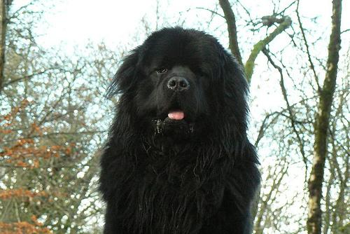

a photo of a dog                                   cosine=+0.2790  candidate share=0.998
a photo of a cat                                   cosine=+0.2128  candidate share=0.001
a photo of a bird                                  cosine=+0.2073  candidate share=0.001
Now change the task:


a photo of a Newfoundland                          cosine=+0.3332  candidate share=1.000
a photo of a pug                                   cosine=+0.2330  candidate share=0.000
a photo of a Persian cat                           cosine=+0.2222  candidate share=0.000


In [3]:
def compare(image_id, descriptions):
    v=encode_text(descriptions); cosine=(U[by_id[image_id]]@v.T).cpu().numpy()
    share=torch.tensor(cosine*model.logit_scale.exp().item()).softmax(-1).numpy()
    for j in np.argsort(-cosine):print(f'{descriptions[j]:50} cosine={cosine[j]:+.4f}  candidate share={share[j]:.3f}')
    return cosine

display(read_image(gallery[by_id['newfoundland']]).resize((350,234)))
compare('newfoundland',['a photo of a dog','a photo of a cat','a photo of a bird'])
print('Now change the task:')
compare('newfoundland',['a photo of a Newfoundland','a photo of a pug','a photo of a Persian cat']);

## 2. Search, without filenames
The gallery is encoded once. A query changes only the text vector. [Application inspiration: Supabase](https://www.youtube.com/watch?v=S7VZErcTN5Y&t=414s). Try a query that has no good answer too.

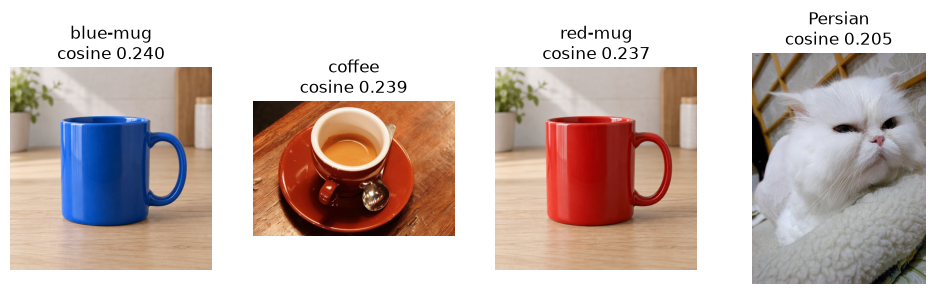

In [4]:
query='something to drink'  # Try: a pet / a spacecraft taking off / a laptop
scores=(U@encode_text([query]).T).squeeze().cpu().numpy()
fig,axes=plt.subplots(1,4,figsize=(12,3))
for ax,j in zip(axes,np.argsort(-scores)[:4]):
    ax.imshow(read_image(gallery[j]));ax.set_title(f"{gallery[j]['id']}\ncosine {scores[j]:.3f}");ax.axis('off')
plt.show()

## 3. What changed? Test a direction
[CodeEmporium’s hat experiment](https://www.youtube.com/watch?v=FCDKn-vpn_o&t=445s) motivates this. These paired pictures are generated specifically for this lesson. The chimney, device, colour and style pairs are our extensions. No CodeEmporium photos are redistributed.

Normalize each image vector, subtract **after − before**, normalize the difference, then compare to text. There is no trained change-detection head and no guarantee of clean semantic subtraction. The synthetic medical pair is not anatomically validated or a clinical experiment.

In [5]:
def difference(before,after,words):
    delta=U[by_id[after]]-U[by_id[before]]
    assert delta.norm()>1e-8
    delta=delta/delta.norm()
    sims=(delta@encode_text(words).T).cpu().numpy()
    for j in np.argsort(-sims):print(f'{words[j]:20} {sims[j]:+.4f}')
    return sims

for ex in [e for e in experiments if e['mode']=='difference']:
    print('\n'+ex['title'])
    difference(ex['image'],ex['second'],ex['candidates'])


What changed?
hat                  +0.1865
boat                 +0.0281
cup                  +0.0134
cat                  -0.0113

A second subtraction experiment
blue                 +0.2156
hat                  +0.0419
cup                  +0.0347
red                  -0.2275

Add a chimney
chimney              +0.1481
tree                 +0.0849
truck                +0.0367
solar panel          +0.0178

Add a visible medical device
stethoscope          +0.1093
pacemaker            +0.0533
hat                  +0.0340
rib                  -0.0219

Change style, keep the dog


pencil sketch        +0.2053
photograph           +0.0201
dog                  +0.0079
cat                  +0.0058


**Work it out:** reverse the pair. Every cosine must change sign if the text vectors stay fixed. Does the top label remain top? Which extra scene details changed besides the intended object?

In [6]:
a=difference('portrait','portrait-hat',['hat','cup','cat','boat'])
b=difference('portrait-hat','portrait',['hat','cup','cat','boat'])
np.testing.assert_allclose(a,-b,atol=1e-6)
print('Reversal check passed.')

hat                  +0.1865
boat                 +0.0281
cup                  +0.0134
cat                  -0.0113
cat                  +0.0113
cup                  -0.0134
boat                 -0.0281
hat                  -0.1865
Reversal check passed.


## 4. Domain transfer is a question, not a promise
Use descriptions for public medical imagery, synthetic overhead landscapes and generated sketches. The public chest radiograph is credited to Stillwaterising (CC0). The satellite-style panels are fictional scenes, not observations of actual sites. Matching an imaging modality does not demonstrate disease diagnosis.

In [7]:
for id in ['sustainability','healthcare','sketch','negation','competition']:
    ex=next(x for x in experiments if x['id']==id)
    print('\n'+ex['title']);compare(ex['image'],ex['candidates'])


Search an overhead landscape
an aerial image of a brick kiln                    cosine=+0.3606  candidate share=0.999
an aerial image of industrial warehouses           cosine=+0.2834  candidate share=0.000
an aerial image of agricultural fields             cosine=+0.2814  candidate share=0.000
an aerial image of a solar farm                    cosine=+0.2725  candidate share=0.000

Recognize the kind of medical image


a chest X-ray                                      cosine=+0.3140  candidate share=1.000
an X-ray of a hand                                 cosine=+0.2348  candidate share=0.000
a photograph of a person                           cosine=+0.2151  candidate share=0.000
a brain MRI scan                                   cosine=+0.1581  candidate share=0.000

Keep the concept; change the style


a drawing of a dog                                 cosine=+0.3312  candidate share=0.997
a drawing of a horse                               cosine=+0.2678  candidate share=0.002
a drawing of a cat                                 cosine=+0.2531  candidate share=0.000
a drawing of a fox                                 cosine=+0.2522  candidate share=0.000

Try to break the model
a photo of a cat                                   cosine=+0.2845  candidate share=0.978
a photo without a cat                              cosine=+0.2448  candidate share=0.019
a photo of a dog                                   cosine=+0.2269  candidate share=0.003

Remove the right answer


a photo of a cat                                   cosine=+0.2128  candidate share=0.615
a photo of a bird                                  cosine=+0.2073  candidate share=0.357
a photo of a car                                   cosine=+0.1817  candidate share=0.028


## 5. Two directions, one score matrix
[Radford et al., Figure 1 and §2.2](https://proceedings.mlr.press/v139/radford21a.html). Rows are images; columns are descriptions. For training, paired image i and text i supply diagonal targets. Row softmax answers “which caption?”; column softmax answers “which image?”.

In [8]:
ids=['newfoundland','Persian','pug']
texts=['a photo of a Newfoundland','a photo of a Persian cat','a photo of a pug']
A=U[[by_id[i] for i in ids]]; B=encode_text(texts)
cosine=A@B.T
logits=model.logit_scale.exp()*cosine
target=torch.arange(3)
loss_i=torch.nn.functional.cross_entropy(logits,target)
loss_t=torch.nn.functional.cross_entropy(logits.T,target)
print('Cosine matrix:\n',cosine)
print('Row probabilities:\n',logits.softmax(1))
print('Column probabilities:\n',logits.softmax(0))
print('Symmetric loss:',((loss_i+loss_t)/2).item())
# This diagnoses these three selected pairs; it is not a training or benchmark claim.
assert torch.allclose(logits.softmax(1).sum(1),torch.ones(3),atol=1e-5)

Cosine matrix:
 tensor([[0.3332, 0.2222, 0.2330],
        [0.1956, 0.3202, 0.1805],
        [0.2168, 0.1932, 0.3224]])
Row probabilities:
 tensor([[9.9994e-01, 1.5073e-05, 4.4495e-05],
        [3.8646e-06, 1.0000e+00, 8.5981e-07],
        [2.5772e-05, 2.4459e-06, 9.9997e-01]], grad_fn=<SoftmaxBackward0>)
Column probabilities:
 tensor([[9.9999e-01, 5.5223e-05, 1.3070e-04],
        [1.0548e-06, 9.9994e-01, 6.8933e-07],
        [8.7733e-06, 3.0503e-06, 9.9987e-01]], grad_fn=<SoftmaxBackward0>)
Symmetric loss: 4.86551653011702e-05


## 6. Watch alignment being learned, from scratch
We now switch models and data deliberately. This small experiment trains a CNN image encoder and a two-token learned text encoder from random initialization on **270 coloured-shape images**. It uses no CLIP weights or pretrained features. There are nine familiar colour–shape descriptions. Ninety held-out images vary position, size, shade and background; the nine concepts themselves are not unseen.

We keep one item per concept in each batch so identical descriptions are not treated as negatives. Both encoders and a log scale learn with the same bidirectional contrastive loss. The fixed 500-step budget is specified before evaluation. This is a demonstration of learning alignment, not a small reproduction of web-scale CLIP. [Objective source: Radford et al.](https://proceedings.mlr.press/v139/radford21a.html).

In [9]:
sys.path.insert(0,str(ROOT/'scripts'))
from train_tiny import train
training=train(steps=500,seed=7,write=False)
print(f"Held-out accuracy: {training['before']['accuracy']:.1%} → {training['after']['accuracy']:.1%}")
assert training['split_overlap'] is False
assert training['after']['accuracy']>training['before']['accuracy']

{
  "train_images": 270,
  "test_images": 90,
  "parameters": 104201,
  "seconds": 1.2094473838806152
}
Accuracy before 0.1111111119389534 after 0.9888888597488403
Held-out accuracy: 11.1% → 98.9%


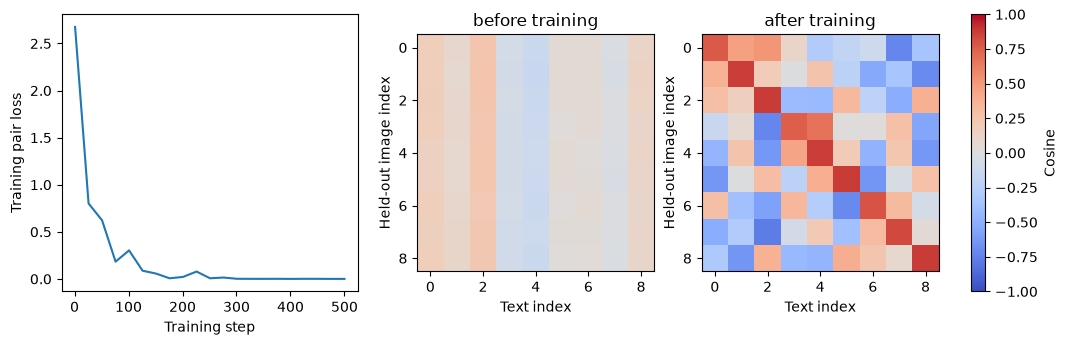

In [10]:
fig,axes=plt.subplots(1,3,figsize=(13,3.6))
axes[0].plot([h['step'] for h in training['history']],[h['train_loss'] for h in training['history']]);axes[0].set(xlabel='Training step',ylabel='Training pair loss')
for ax,key in zip(axes[1:],['before','after']):
    # One held-out image per concept; same examples before and after.
    indices=np.arange(9)*10
    im=ax.imshow(np.asarray(training[key]['cosine'])[indices],vmin=-1,vmax=1,cmap='coolwarm')
    ax.set(title=key+' training',xlabel='Text index',ylabel='Held-out image index')
plt.colorbar(im,ax=axes[1:],label='Cosine');plt.show()

## 7. Inspect the code; rerun a meaningful ablation
The source below is the exact implementation just executed. Try training with shuffled pair targets or freezing one encoder, keeping the same test split and fixed step budget. Record all runs; do not select a checkpoint using test accuracy.

The toy model’s text path concatenates two learned token embeddings and projects them. It is intentionally smaller than CLIP’s causal Transformer. Its CNN image path replaces the ViT. The shared-space projections, normalization, temperature, score matrix and loss are the mechanisms under study.

In [11]:
print((ROOT/'scripts/train_tiny.py').read_text())

"""Train both encoders from random initialization on a tiny paired synthetic dataset.
No OpenAI CLIP weights, no pretrained features, no fitted evaluation images.
"""
from pathlib import Path
import hashlib,json,random,time
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from PIL import Image,ImageDraw
ROOT=Path(__file__).resolve().parents[1]
COLORS={'red':(220,45,45),'green':(30,155,75),'blue':(45,90,220)}
SHAPES=['circle','square','triangle']
LABELS=[f'{c} {s}' for c in COLORS for s in SHAPES]

def dataset(seed,n):
 rng=np.random.default_rng(seed);images=[];labels=[];raw=[]
 for label in range(9):
  color=list(COLORS.values())[label//3];shape=SHAPES[label%3]
  for _ in range(n):
   bg=int(rng.integers(230,256));im=Image.new('RGB',(32,32),(bg,bg,bg));d=ImageDraw.Draw(im)
   size=int(rng.integers(12,23));x=int(rng.integers(2,31-size));y=int(rng.integers(2,31-size))
   rgb=tuple(int(np.clip(v+rng.integers(-16,17),0,255)) for v in color)
   if sh

## References and ownership
- [CLIP paper](https://proceedings.mlr.press/v139/radford21a.html) and [OpenAI implementation](https://github.com/openai/CLIP).
- [CodeEmporium](https://www.youtube.com/watch?v=FCDKn-vpn_o): mechanism walkthrough and hat-vector experiment.
- [Computerphile](https://www.youtube.com/watch?v=KcSXcpluDe4): why fixed labels are limiting; representation before downstream use.
- [Yannic Kilcher](https://www.youtube.com/watch?v=T9XSU0pKX2E): paired matching objective and zero-shot classifier construction.
- [Data Science Gems](https://www.youtube.com/watch?v=rdMnjvjSAkQ): task diversity, prompt context and evaluation.
- [Supabase](https://www.youtube.com/watch?v=S7VZErcTN5Y): gallery search.
- [Roboflow](https://www.youtube.com/watch?v=YxJkE6FvGF4&t=640s): image embeddings, similarity and dataset exploration.
- [Image provenance and generated-image prompts](https://nipunbatra.github.io/clip-lab/sources.html).

The classroom exercises, tiny shape dataset, tiny model implementation and experimental extensions are newly authored for this lab. Source ideas remain credited. Generated pictures are synthetic teaching material; measured model outputs remain measured results, including failures.